In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\HP\Desktop\SEM 7\capestone\SupplyChainOptimisation\Data\preprocessed\cleaned.csv",encoding="latin1")
df

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Fname,...,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Product Status,Shipping Mode
0,CASH,2,4,239.979996,Advance shipping,0,Camping & Hiking,Hickory,United States,Mary,...,299.980011,239.979996,88.790001,Central America,Distrito Federal,CLOSED,Diamondback Women's Serene Classic Comfort Bi,299.980011,0,Standard Class
1,PAYMENT,3,4,193.990005,Advance shipping,0,Water Sports,Chicago,United States,David,...,199.990005,193.990005,91.180000,South America,Risaralda,PENDING_PAYMENT,Pelican Sunstream 100 Kayak,199.990005,0,Standard Class
2,PAYMENT,3,4,227.500000,Advance shipping,0,Women's Apparel,Chicago,United States,David,...,250.000000,227.500000,68.250000,South America,Risaralda,PENDING_PAYMENT,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,Standard Class
3,PAYMENT,3,4,107.889999,Advance shipping,0,Men's Footwear,Chicago,United States,David,...,129.990005,107.889999,36.470001,South America,Risaralda,PENDING_PAYMENT,Nike Men's CJ Elite 2 TD Football Cleat,129.990005,0,Standard Class
4,CASH,5,4,159.940002,Late delivery,1,Indoor/Outdoor Games,San Antonio,United States,Brian,...,199.919998,159.940002,33.590000,South America,Risaralda,CLOSED,O'Brien Men's Neoprene Life Vest,49.980000,0,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,TRANSFER,6,4,161.869995,Late delivery,1,Women's Clothing,Caguas,Puerto Rico,Chava,...,215.820007,161.869995,-107.959999,Southeast Asia,Java Occidental,PROCESSING,Summer dresses,215.820007,0,Standard Class
180515,DEBIT,2,4,172.660004,Advance shipping,0,Women's Clothing,Plainfield,United States,Stacey,...,215.820007,172.660004,-126.559998,Southeast Asia,Java Occidental,COMPLETE,Summer dresses,215.820007,0,Standard Class
180516,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Cally,...,327.750000,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,Smart watch,327.750000,0,Standard Class
180517,PAYMENT,4,4,10.910000,Shipping on time,0,Toys,Berwyn,United States,Cherokee,...,11.540000,10.910000,1.530000,Southeast Asia,Java Occidental,PENDING_PAYMENT,Toys,11.540000,0,Standard Class


In [4]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer City', 'Customer Country', 'Customer Fname',
       'Customer Lname', 'Customer Segment', 'Customer State',
       'Customer Street', 'Customer Zipcode', 'Department Name', 'Market',
       'Order City', 'Order Country', 'Order Date', 'Order Id',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Name', 'Product Price', 'Product Status', 'Shipping Mode'],
      dtype='object')

In [5]:
df['Product Name'].unique()

array(["Diamondback Women's Serene Classic Comfort Bi",
       'Pelican Sunstream 100 Kayak',
       "Nike Men's Dri-FIT Victory Golf Polo",
       "Nike Men's CJ Elite 2 TD Football Cleat",
       "O'Brien Men's Neoprene Life Vest",
       'Team Golf New England Patriots Putter Grip',
       'Perfect Fitness Perfect Rip Deck', 'Glove It Imperial Golf Towel',
       "Nike Men's Free 5.0+ Running Shoe",
       "Glove It Women's Mod Oval 3-Zip Carry All Gol",
       "Under Armour Girls' Toddler Spine Surge Runni",
       "Nike Women's Legend V-Neck T-Shirt",
       "Under Armour Women's Ignite Slide",
       'Field & Stream Sportsman 16 Gun Fire Safe',
       'Bridgestone e6 Straight Distance NFL San Dieg',
       "Glove It Women's Mod Oval Golf Glove",
       "Under Armour Men's Tech II T-Shirt",
       "adidas Kids' F5 Messi FG Soccer Cleat",
       'Team Golf Tennessee Volunteers Putter Grip',
       'Bridgestone e6 Straight Distance NFL Tennesse',
       'Glove It Urban Brick Golf To

In [6]:
df['Order Region'] = df['Order Region'].str.strip()
df['Product Name'] = df['Product Name'].str.strip()


Filter regions - [('Western Europe', 15.01725580132839), ('Southern Europe', 5.224380813100006), ('East of USA', 3.8306217074103004), ('West Africa', 2.0474299104249414), ('Canada', 0.5312460184246534)]


In [7]:
data = df[df["Order Region"].isin(['Western Europe','Southern Europe','East of USA','West Africa','Canada'])]

In [8]:
data.shape

(48110, 36)

In [9]:
data.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer City', 'Customer Country', 'Customer Fname',
       'Customer Lname', 'Customer Segment', 'Customer State',
       'Customer Street', 'Customer Zipcode', 'Department Name', 'Market',
       'Order City', 'Order Country', 'Order Date', 'Order Id',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Name', 'Product Price', 'Product Status', 'Shipping Mode'],
      dtype='object')

In [10]:
data.drop(columns=['Customer Fname','Customer Lname','Customer Street','Customer Zipcode','Customer State'],inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_19200\1401370563.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=['Customer Fname','Customer Lname','Customer Street','Customer Zipcode','Customer State'],inplace=True)


In [11]:
for region in data['Order Region'].unique():
    print('Number of rows for',region,(data['Order Region']==region).sum())

Number of rows for Western Europe 27109
Number of rows for Southern Europe 9431
Number of rows for East of USA 6915
Number of rows for West Africa 3696
Number of rows for Canada 959


In [12]:
data.groupby('Order Region')['Order Id'].nunique()

Order Region
Canada               309
East of USA         2323
Southern Europe     3543
West Africa         1223
Western Europe     10010
Name: Order Id, dtype: int64

In [13]:
data[(data['Category Name']=='Cleats') & (data['Order Region']=='Western Europe')].loc[:,'Order Item Quantity'].sum()

np.int64(10977)

## PRODUCT CATEGORY WISE

For EDA, “Avg Quantity per Order (%)” is perfect (fair comparison despite imbalance).  
vg Quantity per Order (%) = 14.88%  
Each order in Canada contains, on average, about 0.15 Accessories items per order, i.e., Accessories make up 14.9% of the total quantity of items purchased per order.  
total quanity sold for that category in that region/ Total number of orders in that region


In [14]:
data['Sales per Order'] = data['Sales'] / data['Order Item Quantity']
region_category_sales = (
    data.groupby(['Order Region', 'Category Name']).agg({
        'Sales':'sum',
        'Order Item Quantity':'sum',
        'Sales per Order':'mean',
        'Order Profit Per Order':'mean'
    })
    .reset_index()
)

region_orders = data.groupby('Order Region')['Order Id'].nunique().reset_index()
region_orders.rename(columns={'Order Id': 'Total Orders'}, inplace=True)

region_category_sales = region_category_sales.merge(region_orders, on='Order Region', how='left')

region_category_sales['Avg Quantity per Order'] = (
    (region_category_sales['Order Item Quantity'] / region_category_sales['Total Orders'])
)


region_category_sales['Avg Sales per Order'] = (
    region_category_sales['Sales'] / region_category_sales['Total Orders']
)

region_category_sales


C:\Users\HP\AppData\Local\Temp\ipykernel_19200\3481786183.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Sales per Order'] = data['Sales'] / data['Order Item Quantity']


,Order Region,Category Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
0,Canada,Accessories,1149.539995,46,24.990000,23.229286,309,0.148867,3.720194
1,Canada,Baseball & Softball,104.970001,3,34.990000,30.440001,309,0.009709,0.339709
2,Canada,Boxing & MMA,769.580017,14,54.970001,35.372500,309,0.045307,2.490550
3,Canada,Camping & Hiking,24298.380891,81,299.980011,30.008518,309,0.262136,78.635537
4,Canada,Cardio Equipment,24587.549996,248,98.148157,45.754737,309,0.802589,79.571359
...,...,...,...,...,...,...,...,...,...
149,Western Europe,Tennis & Racquet,3869.140041,86,44.990001,17.867500,10010,0.008591,0.386527
150,Western Europe,Trade-In,10757.340086,266,77.475150,14.303564,10010,0.026573,1.074659
151,Western Europe,Water Sports,475376.422607,2359,201.516076,18.040208,10010,0.235664,47.490152
152,Western Europe,Women's Apparel,475500.000000,9510,50.000000,18.046348,10010,0.950050,47.502498


In [15]:
for region in data['Order Region'].unique():
    top5 = (
        region_category_sales[region_category_sales['Order Region'] == region]
        .nlargest(5, columns=['Avg Quantity per Order'])
    )
    print(f"\nTop 7 Categories in {region}:")
    pd.DataFrame(top5)
    display(top5)


Top 7 Categories in Western Europe:


,Order Region,Category Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
125,Western Europe,Cleats,664030.248013,10977,61.485936,22.295672,10010,1.096603,66.336688
152,Western Europe,Women's Apparel,475500.000000,9510,50.000000,18.046348,10010,0.950050,47.502498
141,Western Europe,Indoor/Outdoor Games,407486.936365,8153,49.980000,18.620029,10010,0.814486,40.707986
123,Western Europe,Cardio Equipment,562804.079554,5714,98.372583,26.152920,10010,0.570829,56.224184
146,Western Europe,Shop By Sport,202710.883237,5020,41.601565,10.302127,10010,0.501499,20.250837



Top 7 Categories in Southern Europe:


,Order Region,Category Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
60,Southern Europe,Cleats,221723.366033,3664,61.524774,22.217354,3543,1.034152,62.580685
87,Southern Europe,Women's Apparel,162000.000000,3240,50.000000,18.419465,3543,0.914479,45.723963
76,Southern Europe,Indoor/Outdoor Games,148840.438695,2978,49.980000,18.836530,3543,0.840531,42.009720
58,Southern Europe,Cardio Equipment,184671.629683,1870,98.766009,30.462305,3543,0.527801,52.122955
81,Southern Europe,Shop By Sport,65923.871173,1639,40.937396,14.687450,3543,0.462602,18.606794



Top 7 Categories in East of USA:


,Order Region,Category Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
29,East of USA,Cleats,170011.664718,2834,59.990002,18.244164,2323,1.219974,73.186253
47,East of USA,Women's Apparel,127600.000000,2552,50.000000,17.907870,2323,1.098579,54.928971
40,East of USA,Indoor/Outdoor Games,111805.258959,2237,49.980000,19.894396,2323,0.962979,48.129685
28,East of USA,Cardio Equipment,148525.259734,1512,97.869090,31.588849,2323,0.650882,63.936832
43,East of USA,Shop By Sport,56336.310837,1422,39.587861,13.387648,2323,0.612139,24.251533



Top 7 Categories in West Africa:


,Order Region,Category Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
94,West Africa,Cleats,93404.432702,1557,59.990002,19.222520,1223,1.273099,76.373207
112,West Africa,Women's Apparel,71150.000000,1423,50.000000,9.429401,1223,1.163532,58.176615
105,West Africa,Indoor/Outdoor Games,63424.619354,1269,49.980000,15.897718,1223,1.037612,51.859869
93,West Africa,Cardio Equipment,77772.269950,789,98.405320,38.876792,1223,0.645135,63.591390
108,West Africa,Shop By Sport,26843.460412,677,39.728254,11.067031,1223,0.553557,21.948864



Top 7 Categories in Canada:


,Order Region,Category Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
5,Canada,Cleats,25675.720742,428,59.990002,22.116414,309,1.385113,83.092947
23,Canada,Women's Apparel,17500.000000,350,50.000000,10.945178,309,1.132686,56.634304
16,Canada,Indoor/Outdoor Games,16693.319881,334,49.980000,16.433853,309,1.080906,54.023689
4,Canada,Cardio Equipment,24587.549996,248,98.148157,45.754737,309,0.802589,79.571359
19,Canada,Shop By Sport,7448.220088,189,39.345485,8.244193,309,0.611650,24.104272


C:\Users\HP\AppData\Local\Temp\ipykernel_19200\3169517886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


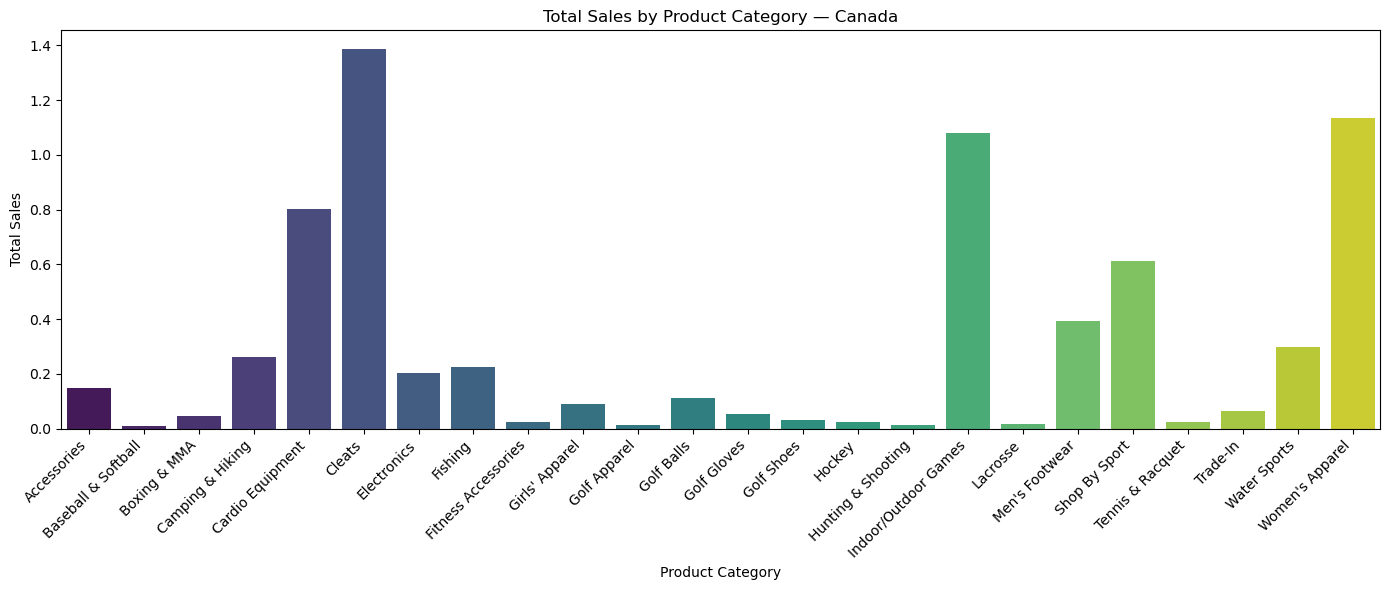

C:\Users\HP\AppData\Local\Temp\ipykernel_19200\3169517886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


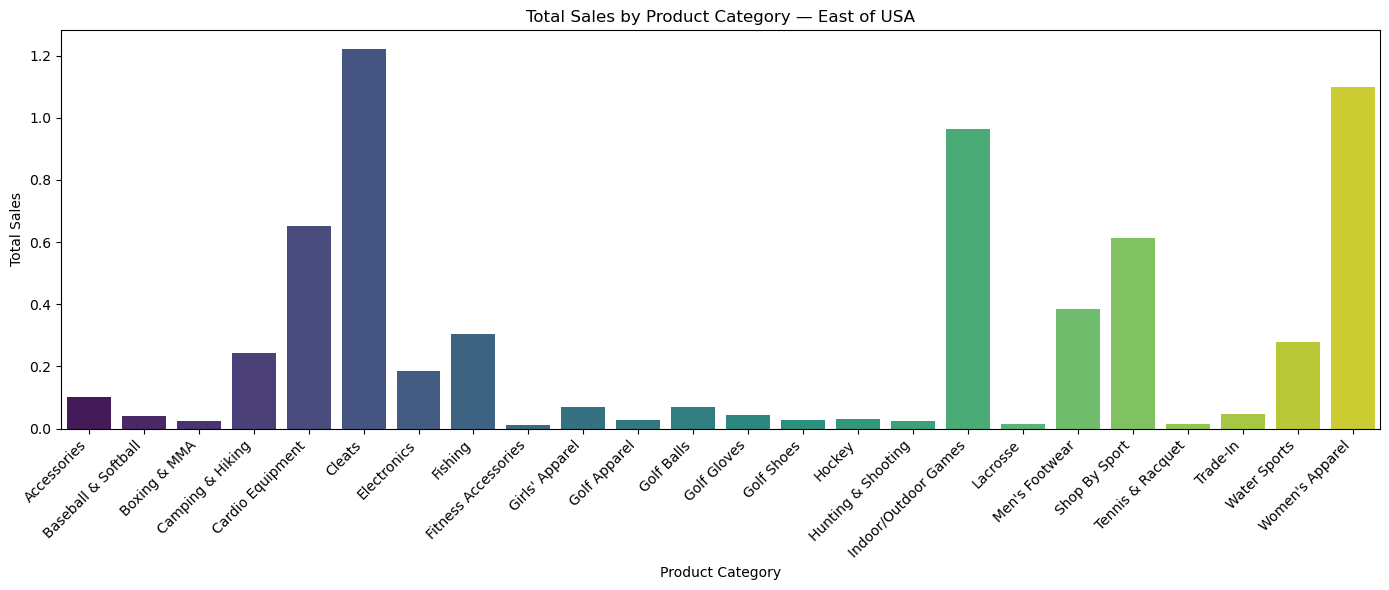

C:\Users\HP\AppData\Local\Temp\ipykernel_19200\3169517886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


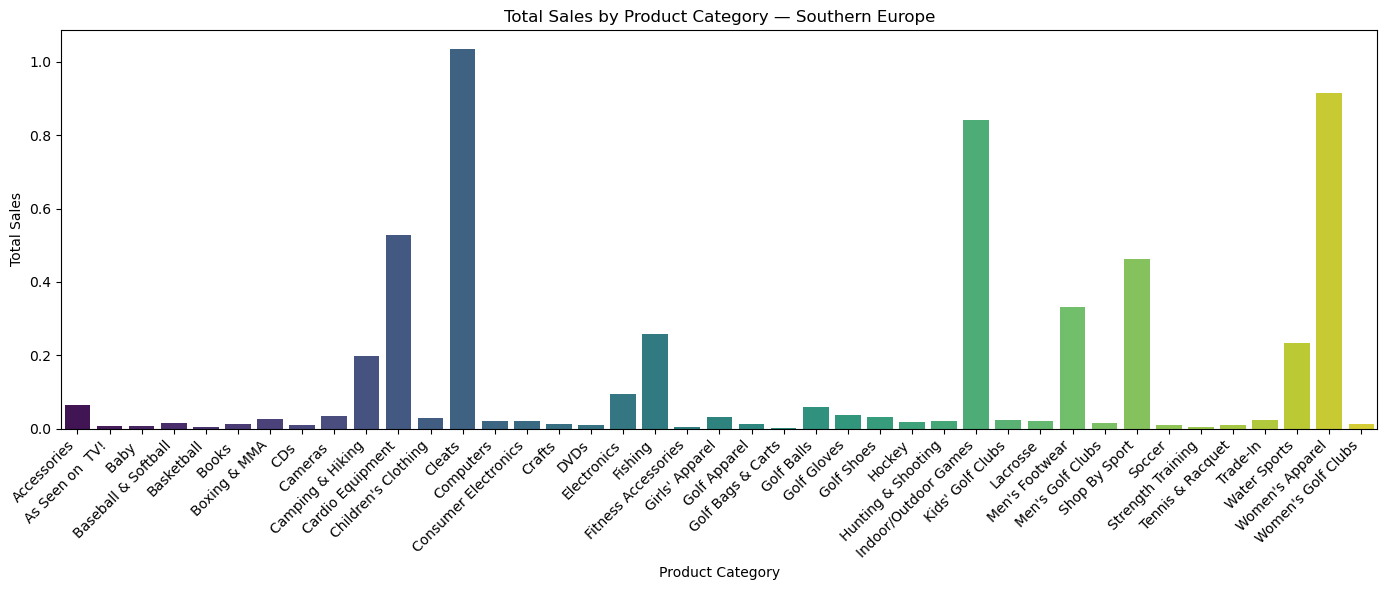

C:\Users\HP\AppData\Local\Temp\ipykernel_19200\3169517886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


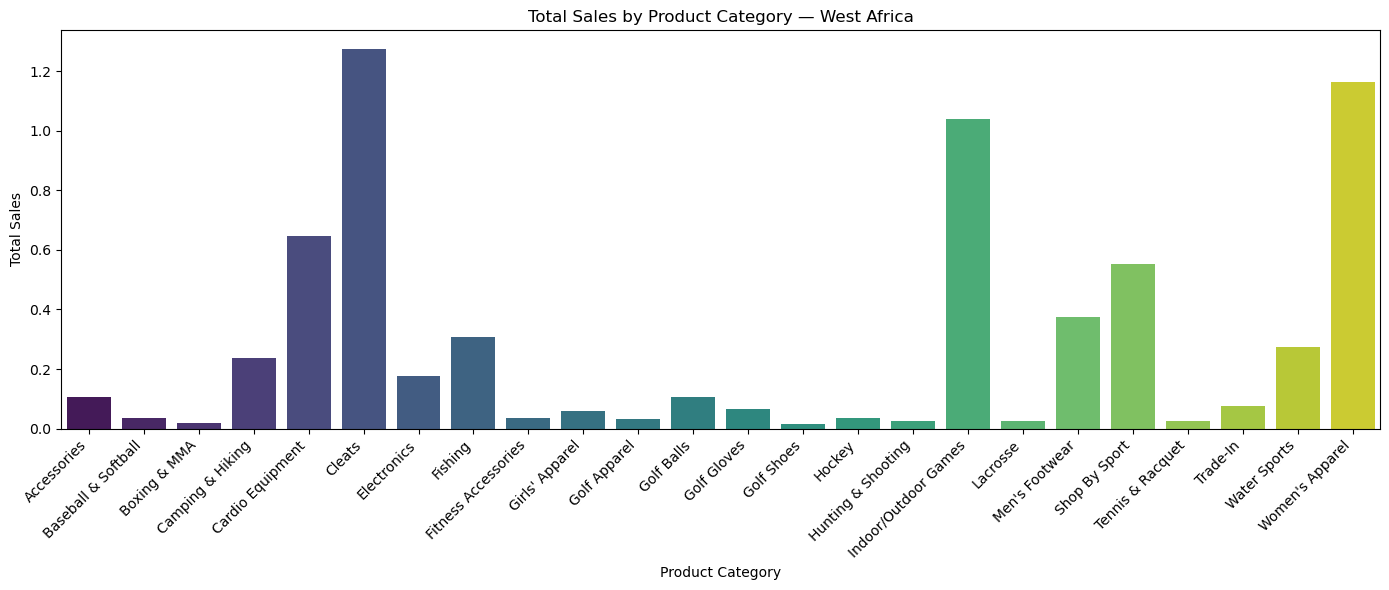

C:\Users\HP\AppData\Local\Temp\ipykernel_19200\3169517886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


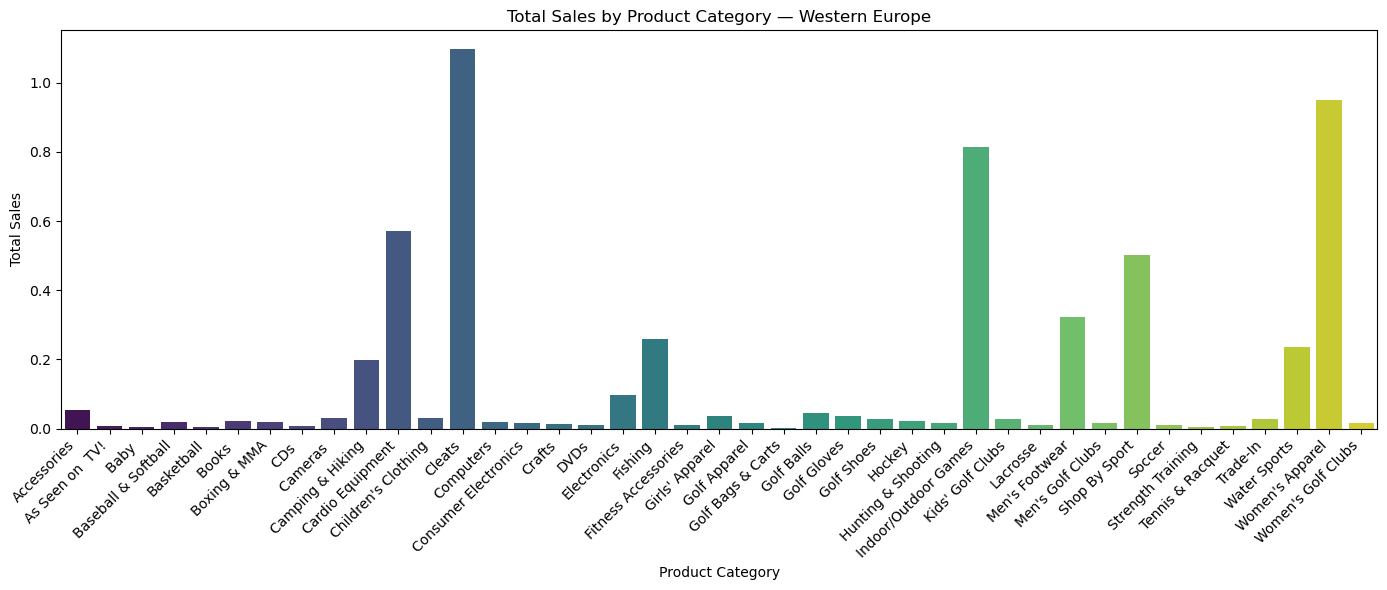

In [16]:
regions = region_category_sales['Order Region'].unique()

for region in regions:
    subset = region_category_sales[region_category_sales['Order Region'] == region]

    plt.figure(figsize=(14,6))
    sns.barplot(
        data=subset,
        x='Category Name',
        y='Avg Quantity per Order',
        palette='viridis',
    )
    plt.title(f'Total Sales by Product Category — {region}')
    plt.xlabel('Product Category')
    plt.ylabel('Total Sales')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## PRODUCT NAME WISE: TOP 5 PRODUCTS  


In [17]:
data['Product Name'].nunique()

109

In [18]:
region_product_sales = (
    data.groupby(['Order Region', 'Product Name']).agg({
        'Sales':'sum',
        'Order Item Quantity':'sum',
        'Sales per Order':'mean',
        'Order Profit Per Order':'mean'
    })
    .reset_index()
)

region_orders = data.groupby('Order Region')['Order Id'].nunique().reset_index()
region_orders.rename(columns={'Order Id': 'Total Orders'}, inplace=True)

region_product_sales = region_product_sales.merge(region_orders, on='Order Region', how='left')

region_product_sales['Avg Quantity per Order'] = (
    (region_product_sales['Order Item Quantity'] / region_product_sales['Total Orders'])
)


region_product_sales['Avg Sales per Order'] = (
    region_product_sales['Sales'] / region_product_sales['Total Orders']
)

region_product_sales

,Order Region,Product Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
0,Canada,Bridgestone e6 Straight Distance NFL Carolina,351.889999,11,31.990000,-5.629999,309,0.035599,1.138803
1,Canada,Bridgestone e6 Straight Distance NFL Tennesse,191.939997,6,31.990000,-1.925000,309,0.019417,0.621165
2,Canada,Clicgear 8.0 Shoe Brush,79.920000,8,9.990000,-11.900000,309,0.025890,0.258641
3,Canada,Clicgear Rovic Cooler Bag,359.910000,9,39.990000,33.376668,309,0.029126,1.164757
4,Canada,Columbia Men's PFG Anchor Tough T-Shirt,330.000000,11,30.000000,22.210000,309,0.035599,1.067961
...,...,...,...,...,...,...,...,...,...
369,Western Europe,adidas Kids' F5 Messi FG Soccer Cleat,2449.300048,70,34.990001,0.934546,10010,0.006993,0.244685
370,Western Europe,adidas Men's F10 Messi TRX FG Soccer Cleat,5219.130154,87,59.990002,14.884286,10010,0.008691,0.521392
371,Western Europe,adidas Men's Germany Black Crest Away Tee,1650.000000,66,25.000000,4.192800,10010,0.006593,0.164835
372,Western Europe,adidas Youth Germany Black/Red Away Match Soc,6790.000000,97,70.000000,11.887647,10010,0.009690,0.678322


In [19]:
for region in data['Order Region'].unique():
    top5 = (
        region_product_sales[region_product_sales['Order Region'] == region]
        .nlargest(5, columns=['Avg Quantity per Order'])
    )
    print(f"\nTop 5 Categories in {region}:")
    pd.DataFrame(top5)
    display(top5)


Top 5 Categories in Western Europe:


,Order Region,Product Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
331,Western Europe,Perfect Fitness Perfect Rip Deck,657130.478238,10954,59.990002,22.215852,10010,1.094306,65.647400
319,Western Europe,Nike Men's Dri-FIT Victory Golf Polo,475500.000000,9510,50.000000,18.046348,10010,0.950050,47.502498
327,Western Europe,O'Brien Men's Neoprene Life Vest,407486.936365,8153,49.980000,18.620029,10010,0.814486,40.707986
321,Western Europe,Nike Men's Free 5.0+ Running Shoe,559144.079554,5592,99.989999,26.442441,10010,0.558641,55.858549
358,Western Europe,Under Armour Girls' Toddler Spine Surge Runni,195671.073133,4893,39.990001,10.540470,10010,0.488811,19.547560



Top 5 Categories in Southern Europe:


,Order Region,Product Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
169,Southern Europe,Perfect Fitness Perfect Rip Deck,219323.446112,3656,59.990002,22.482526,3543,1.031894,61.903315
157,Southern Europe,Nike Men's Dri-FIT Victory Golf Polo,162000.000000,3240,50.000000,18.419465,3543,0.914479,45.723963
165,Southern Europe,O'Brien Men's Neoprene Life Vest,148840.438695,2978,49.980000,18.836530,3543,0.840531,42.009720
159,Southern Europe,Nike Men's Free 5.0+ Running Shoe,183681.629683,1837,99.989999,31.277735,3543,0.518487,51.843531
195,Southern Europe,Under Armour Girls' Toddler Spine Surge Runni,64343.911151,1609,39.990001,14.485760,3543,0.454135,18.160856



Top 5 Categories in East of USA:


,Order Region,Product Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
79,East of USA,Perfect Fitness Perfect Rip Deck,170011.664718,2834,59.990002,18.244164,2323,1.219974,73.186253
73,East of USA,Nike Men's Dri-FIT Victory Golf Polo,127600.000000,2552,50.000000,17.907870,2323,1.098579,54.928971
77,East of USA,O'Brien Men's Neoprene Life Vest,111805.258959,2237,49.980000,19.894396,2323,0.962979,48.129685
74,East of USA,Nike Men's Free 5.0+ Running Shoe,147385.259734,1474,99.989999,32.456125,2323,0.634524,63.446087
92,East of USA,Under Armour Girls' Toddler Spine Surge Runni,54746.310837,1369,39.990001,13.448190,2323,0.589324,23.567073



Top 5 Categories in West Africa:


,Order Region,Product Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
240,West Africa,Perfect Fitness Perfect Rip Deck,93404.432702,1557,59.990002,19.222520,1223,1.273099,76.373207
234,West Africa,Nike Men's Dri-FIT Victory Golf Polo,71150.000000,1423,50.000000,9.429401,1223,1.163532,58.176615
238,West Africa,O'Brien Men's Neoprene Life Vest,63424.619354,1269,49.980000,15.897718,1223,1.037612,51.859869
235,West Africa,Nike Men's Free 5.0+ Running Shoe,77292.269950,773,99.989999,39.664015,1223,0.632052,63.198912
253,West Africa,Under Armour Girls' Toddler Spine Surge Runni,26153.460412,654,39.990001,10.661614,1223,0.534751,21.384677



Top 5 Categories in Canada:


,Order Region,Product Name,Sales,Order Item Quantity,Sales per Order,Order Profit Per Order,Total Orders,Avg Quantity per Order,Avg Sales per Order
27,Canada,Perfect Fitness Perfect Rip Deck,25675.720742,428,59.990002,22.116414,309,1.385113,83.092947
21,Canada,Nike Men's Dri-FIT Victory Golf Polo,17500.000000,350,50.000000,10.945178,309,1.132686,56.634304
25,Canada,O'Brien Men's Neoprene Life Vest,16693.319881,334,49.980000,16.433853,309,1.080906,54.023689
22,Canada,Nike Men's Free 5.0+ Running Shoe,24497.549996,245,99.989999,46.638379,309,0.792880,79.280097
39,Canada,Under Armour Girls' Toddler Spine Surge Runni,7118.220088,178,39.990001,7.281034,309,0.576052,23.036311


## FEATURE ENGINEERING

Feature Engineering: Time based demand for each region for each product category / product  
“Quantity sold per region–product–month”

In [20]:
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')

data['YearMonth'] = data['Order Date'].dt.to_period('M').astype(str)

monthly_product_demand = (
    data.groupby(['Order Region', 'Product Name', 'YearMonth'])['Order Item Quantity']
    .sum()
    .reset_index()
    .rename(columns={'Order Item Quantity': 'Quantity Sold (Monthly)'})
)

data = data.merge(
    monthly_product_demand,
    on=['Order Region', 'Product Name', 'YearMonth'],
    how='left'
)

data = data.sort_values(['Order Region', 'Product Name', 'Order Date']).reset_index(drop=True)


data[['Order Region', 'Product Name', 'YearMonth', 'Quantity Sold (Monthly)']].head(20)

C:\Users\HP\AppData\Local\Temp\ipykernel_19200\3153351963.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')
C:\Users\HP\AppData\Local\Temp\ipykernel_19200\3153351963.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['YearMonth'] = data['Order Date'].dt.to_period('M').astype(str)


,Order Region,Product Name,YearMonth,Quantity Sold (Monthly)
0,Canada,Bridgestone e6 Straight Distance NFL Carolina,2016-10,3
1,Canada,Bridgestone e6 Straight Distance NFL Carolina,2016-12,8
2,Canada,Bridgestone e6 Straight Distance NFL Carolina,2016-12,8
3,Canada,Bridgestone e6 Straight Distance NFL Tennesse,2016-09,5
4,Canada,Bridgestone e6 Straight Distance NFL Tennesse,2017-01,1
5,Canada,Clicgear 8.0 Shoe Brush,2016-08,3
6,Canada,Clicgear 8.0 Shoe Brush,2016-11,5
7,Canada,Clicgear Rovic Cooler Bag,2016-11,6
8,Canada,Clicgear Rovic Cooler Bag,2016-11,6
9,Canada,Clicgear Rovic Cooler Bag,2017-01,3


# lags and rolling stats

In [21]:
data = data.sort_values(['Order Region', 'Product Name', 'YearMonth'])

data['Lag_1'] = data.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].shift(1)
data['Lag_2'] = data.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].shift(2)
data['Lag_3'] = data.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].shift(3)
data['Lag_6'] = data.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].shift(6)
data['Lag_12'] = data.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].shift(12)

data['Rolling_3'] = data.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].transform(lambda x: x.rolling(3).mean())
data['Rolling_6'] = data.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].transform(lambda x: x.rolling(6).mean())


<Axes: >

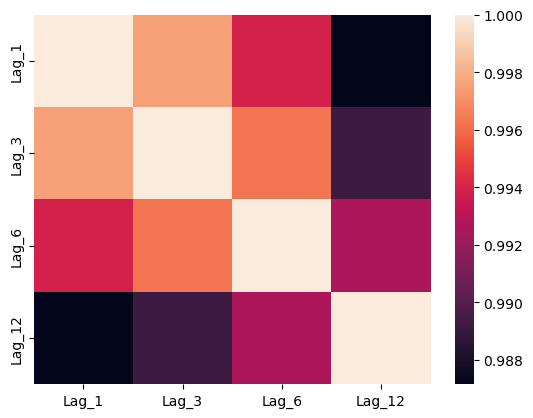

In [22]:
lag_features = data[['Lag_1','Lag_3','Lag_6','Lag_12']]
lag_corr=lag_features.corr()
sns.heatmap(lag_corr)

This time series has very high autocorrelation, meaning it’s quite stable over time, and adjacent periods have very similar values.

## Seasonality

In [23]:
data['YearMonth'] = pd.to_datetime(data['YearMonth'], format='%Y-%m')

data['Year'] = data['YearMonth'].dt.year
data['Month'] = data['YearMonth'].dt.month
data['Quarter'] = data['YearMonth'].dt.quarter

# Optional: holiday or festive demand (depends on domain)
data['IsHolidaySeason'] = data['Month'].isin([11, 12]).astype(int)  # Example: holiday sales boost

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)
df['YearMonth'] = pd.to_datetime(df['YearMonth'], format='%Y-%m')

df['Year'] = df['YearMonth'].dt.year
df['Month'] = df['YearMonth'].dt.month
df['Quarter'] = df['YearMonth'].dt.quarter


## EXAMPLE  
Monthly demand pattern for a product "Perfect Fitness Perfect Rip Deck" accross all 5 regions

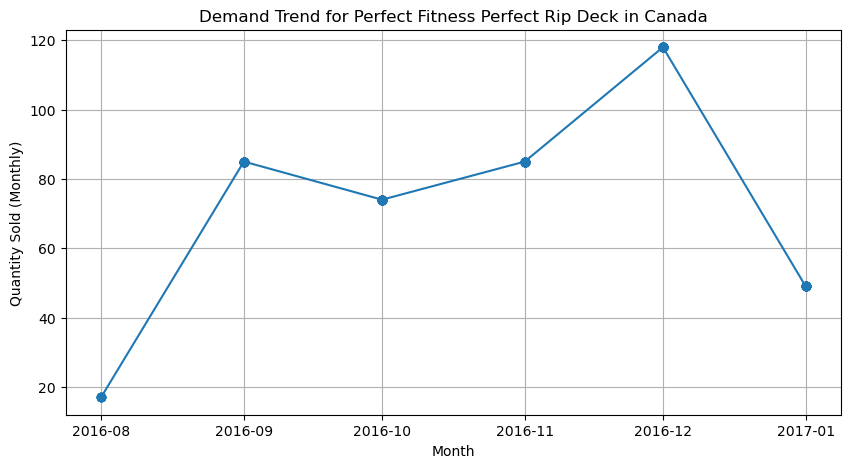

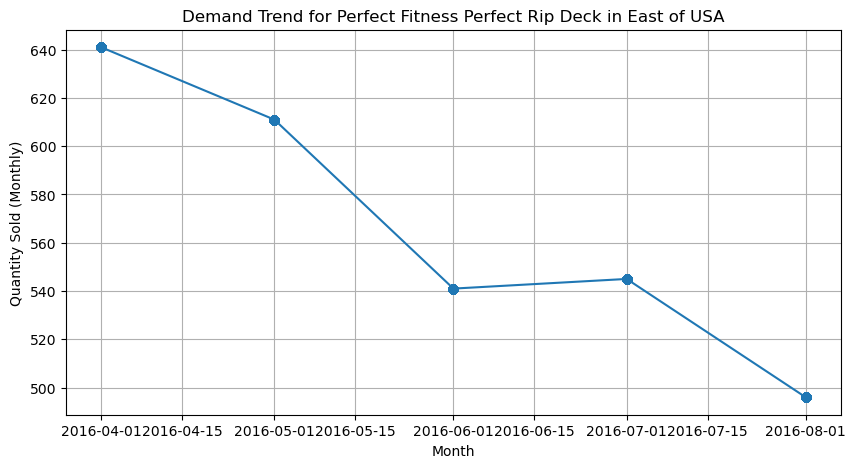

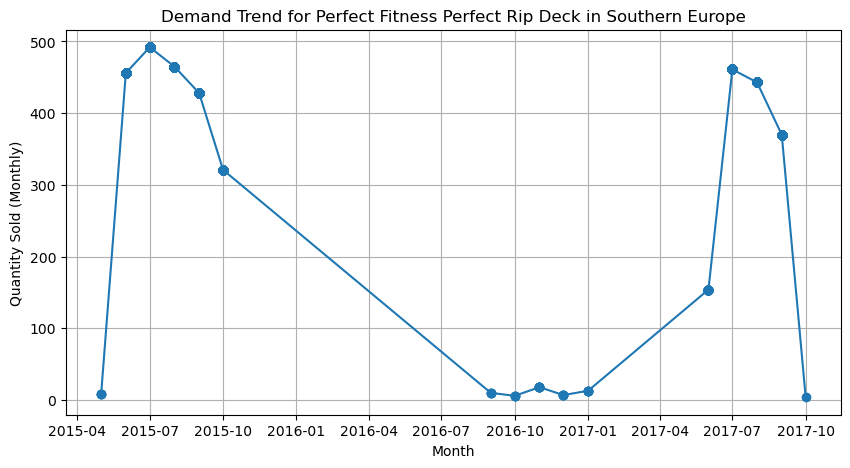

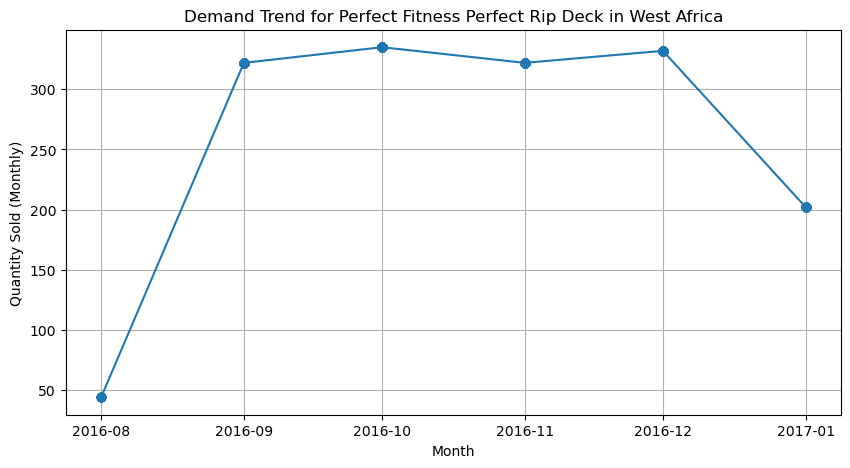

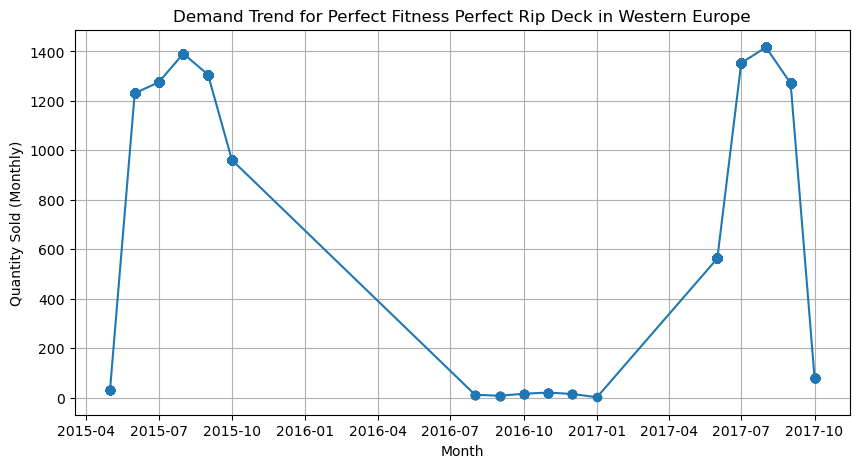

In [24]:
product = "Perfect Fitness Perfect Rip Deck"
for region in data['Order Region'].unique():

    subset = data[(data['Product Name'] == product) & (data['Order Region'] == region)]

    plt.figure(figsize=(10,5))
    plt.plot(subset['YearMonth'], subset['Quantity Sold (Monthly)'], marker='o')
    plt.title(f"Demand Trend for {product} in {region}")
    plt.xlabel("Month")
    plt.ylabel("Quantity Sold (Monthly)")
    plt.grid(True)
    plt.show()


In [25]:
# import os
# save_path = "data/preprocessed"
# os.makedirs(save_path, exist_ok=True)

# data.to_csv(os.path.join(save_path, "transformed2.csv"), index=False, encoding="latin1")

# print("✅ File saved successfully at:", os.path.join(save_path, "transformed2.csv"))

In [26]:
data.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer City', 'Customer Country',
       'Customer Segment', 'Department Name', 'Market', 'Order City',
       'Order Country', 'Order Date', 'Order Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Product Name', 'Product Price',
       'Product Status', 'Shipping Mode', 'Sales per Order', 'YearMonth',
       'Quantity Sold (Monthly)', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_6', 'Lag_12',
       'Rolling_3', 'Rolling_6', 'Year', 'Month', 'Quarter',
       'IsHolidaySeason'],
      dtype='object')

In [35]:
data['YearMonth']

0       2016-10-01
1       2016-12-01
2       2016-12-01
3       2016-09-01
4       2017-01-01
           ...    
48105   2017-08-01
48106   2017-08-01
48107   2017-08-01
48108   2017-09-01
48109   2017-09-01
Name: YearMonth, Length: 48110, dtype: datetime64[ns]

In [40]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

target = 'Quantity Sold (Monthly)'
features = ['Lag_1', 'Lag_3', 'Lag_6', 'Lag_12','Rolling_3', 'Rolling_6']

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=100,
    callbacks=[lgb.early_stopping(10)]
)

y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 45.2545
MAE: 45.25454251103567
R²: 0.9738127358962569


In [42]:
X_test

,Lag_1,Lag_3,Lag_6,Lag_12,Rolling_3,Rolling_6
38488,873.0,873.0,873.0,873.0,873.000000,873.000000
38489,873.0,873.0,873.0,873.0,873.000000,873.000000
38490,873.0,873.0,873.0,873.0,873.000000,873.000000
38491,873.0,873.0,873.0,873.0,873.000000,873.000000
38492,873.0,873.0,873.0,873.0,873.000000,873.000000
...,...,...,...,...,...,...
48105,12.0,12.0,12.0,7.0,12.000000,12.000000
48106,12.0,12.0,12.0,7.0,12.000000,12.000000
48107,12.0,12.0,12.0,7.0,12.000000,12.000000
48108,12.0,12.0,12.0,12.0,8.666667,10.333333


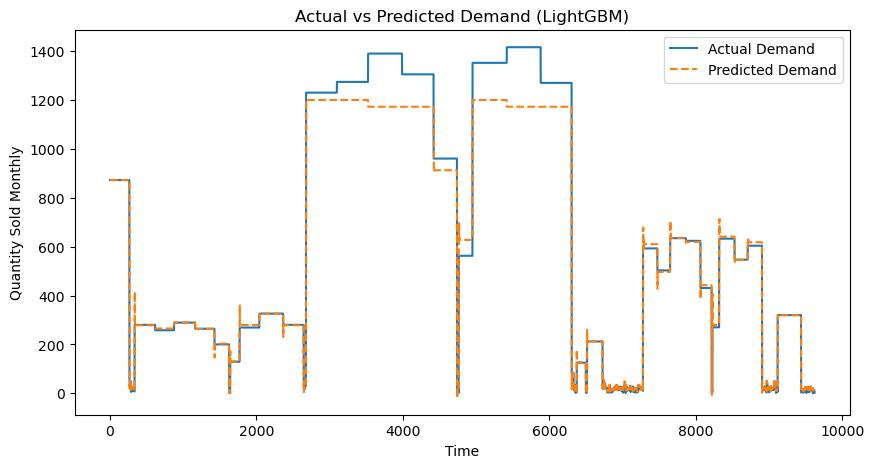

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Demand')
plt.plot(y_pred, label='Predicted Demand', linestyle='--')
plt.title("Actual vs Predicted Demand (LightGBM)")
plt.xlabel("Time")
plt.ylabel("Quantity Sold Monthly")
plt.legend()
plt.show()


CHECK ON SOME DATA

In [30]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

monthly_product_demand = (
    df.groupby(['Order Region', 'Product Name', 'YearMonth'])['Order Item Quantity']
    .sum()
    .reset_index()
    .rename(columns={'Order Item Quantity': 'Quantity Sold (Monthly)'})
)

df = df.merge(
    monthly_product_demand,
    on=['Order Region', 'Product Name', 'YearMonth'],
    how='left'
)

df = df.sort_values(['Order Region', 'Product Name', 'Order Date']).reset_index(drop=True)


In [31]:
df = df.sort_values(['Order Region', 'Product Name', 'YearMonth'])

df['Lag_1'] = df.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].shift(1)
df['Lag_2'] = df.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].shift(2)
df['Lag_3'] = df.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].shift(3)
df['Lag_6'] = df.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].shift(6)
df['Lag_12'] = df.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].shift(12)

df['Rolling_3'] = df.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].transform(lambda x: x.rolling(3).mean())
df['Rolling_6'] = df.groupby(['Order Region', 'Product Name'])['Quantity Sold (Monthly)'].transform(lambda x: x.rolling(6).mean())

In [32]:
product_name = "Under Armour Girls' Toddler Spine Surge Runni"       
region_name = "Central America"

subset = df[(df['Product Name'] == product_name) & (df['Order Region'] == region_name)]
subset = subset.sort_values('Month')  
latest_data = subset.iloc[-1:]

In [33]:
features = ['Lag_1', 'Lag_2', 'Lag_3','Lag_6','Lag_12', 'Rolling_3','Rolling_6','Year', 'Month', 'Quarter'] 
X_latest = latest_data[features]

predicted_demand = model.predict(X_latest)
print(f"Predicted next month's demand for {product_name} in {region_name}: {predicted_demand[0]:.2f}")


Predicted next month's demand for Under Armour Girls' Toddler Spine Surge Runni in Central America: 212.88


In [34]:
product_name = "Under Armour Girls' Toddler Spine Surge Runni"
region_name = "Central America"
subset = df[(df['Product Name'] == product_name) & (df['Order Region'] == region_name)]
subset = subset.sort_values('Month')

subset[['Month', 'Quantity Sold (Monthly)', 'Lag_1', 'Lag_2', 'Lag_3','Lag_6', 'Lag_12','Rolling_3']].tail(5)


,Month,Quantity Sold (Monthly),Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_3
38743,6,212,212.0,212.0,212.0,212.0,212.0,212.0
38712,6,212,212.0,212.0,212.0,212.0,212.0,212.0
38711,6,212,212.0,212.0,212.0,212.0,212.0,212.0
38728,6,212,212.0,212.0,212.0,212.0,212.0,212.0
38727,6,212,212.0,212.0,212.0,212.0,212.0,212.0
